In [1]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\gadia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Random Prüfer code: [1, 6, 2, 1]
Tree edges: [(3, 1), (4, 6), (5, 2), (2, 1), (1, 6)]


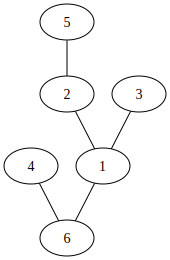

In [13]:
import random
from graphviz import Graph

# ----- Prüfer machinery -----

def random_prufer(n: int) -> list[int]:
    """Generate a random Prüfer code of length n-2 over vertices {1,...,n}."""
    return [random.randint(1, n) for _ in range(n - 2)]

def prufer_to_tree(code: list[int]) -> list[tuple[int, int]]:
    """
    Convert a Prüfer code to the edge list of a tree.
    Vertices are assumed to be {1, ..., n} where n = len(code) + 2.
    """
    n = len(code) + 2
    vertices = list(range(1, n + 1))

    # degree[v] starts at 1 for every vertex, then +1 for each occurrence in the code
    degree = {v: 1 for v in vertices}
    for v in code:
        degree[v] += 1

    edges: list[tuple[int, int]] = []

    # repeatedly connect the smallest leaf to the next code element
    for v in code:
        leaf = min(x for x in vertices if degree[x] == 1)
        edges.append((leaf, v))
        degree[leaf] -= 1
        degree[v] -= 1

    # finally, two vertices of degree 1 remain; connect them
    remaining = [v for v in vertices if degree[v] == 1]
    edges.append((remaining[0], remaining[1]))

    return edges

# ----- Build a random tree on {1,...,6} -----

n = 6
random.seed()  # or set a fixed seed, e.g., random.seed(42) for reproducibility
code = random_prufer(n)
edges = prufer_to_tree(code)

print("Random Prüfer code:", code)
print("Tree edges:", edges)

# ----- Draw with graphviz -----

g = Graph("tree6", format="png")  # undirected graph

# Add vertices explicitly (optional, but makes it clear)
for v in range(1, n + 1):
    g.node(str(v))

# Add edges from Prüfer-derived tree
for u, v in edges:
    g.edge(str(u), str(v))

# This writes tree6.png in the current directory and opens it (if possible)
g.render(filename="tree6")

display(g)


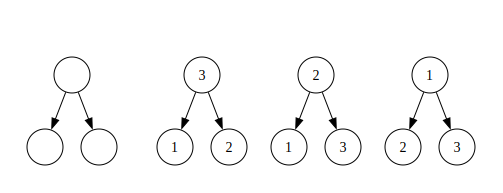

In [ ]:
from graphviz import Source

dot = r"""
draph G {
    graph [rankdir=TB];        // top–bottom layout
    node [shape=circle];

    //--- Create four subgraphs (clusters) to arrange them as a grid ---

    // Row 1: centered graph (empty labels)
    subgraph cluster_top {
        label="No Markings";
        fontsize=20;
        style=invis;

        t [label=""];
        l [label=""];
        r [label=""];

        t -> l;
        t -> r;
    }

    // Row 2: three labeled trees
    subgraph cluster_row2 {
        rank=same;  // put all three on one row
        style=invis;

        // --- labeling #1: 1 < 2 ---
        subgraph cluster1 {
            label="1 < 2";
            fontsize=18;
            style=invis;

            t1 [label="3"];
            l1 [label="1"];
            r1 [label="2"];
            t1 -> l1;
            t1 -> r1;
        }

        // --- labeling #2: 1 < 3 ---
        subgraph cluster2 {
            label="1 < 3";
            fontsize=18;
            style=invis;

            t2 [label="2"];
            l2 [label="1"];
            r2 [label="3"];
            t2 -> l2;
            t2 -> r2;
        }

        // --- labeling #3: 2 < 3 ---
        subgraph cluster3 {
            label="2 < 3";
            fontsize=18;
            style=invis;

            t3 [label="1"];
            l3 [label="2"];
            r3 [label="3"];
            t3 -> l3;
            t3 -> r3;
        }
    }
}

"""

src = Source(dot, filename="four_trees", format="png")
src.render(cleanup=True)
src  # display in notebook